# Reproducing the ODIL solution

For a bit of context, this notebook aims to reproduce the ODIL solution in figure 1 of [the original paper](https://arxiv.org/pdf/2205.04611). 

Figure 1 solves the 1D wave equation,

$$\frac 1 {c^2} u_{tt} = u_{xx},$$

with $c = 1$.

I will attempt to implement ODIL to solve the 1D wave equation in this notebook. The general order of proceedings will be approximately as follows

1. Discretise
2. Formulate the functional (discrete PDE residual + ICs + PML BCs)
3. Optimise (L-BFGS-B, Newton)

We will use the notation that the paper uses, i.e., we can write our generic objective here to be 

$$\text{minimise } L(\mathbf{u}) \text{ subject to } g(u) = 0.$$

## Discretisation

The paper applies ODIL over a rectangular domain $x \in (-1, 1),\, t \in (0, 1)$ on a $25 \times 25$ grid. This then leads to $\Delta x = 0.08,\, \Delta t = 0.04$.

We can approximate the wave equation by finite difference stencils as they do, too. They use central differences derived from Taylor series expansions:

$$u_{tt}(t, x) = \frac {u^{n+1}_i -2u^n_i + u^{n-1}_i} {\Delta t^2} + \mathcal{O}(\Delta t^2), \tag{temporal derivative}$$
$$u_{xx}(t, x)= \frac {u^n_{i+1} -2u^n_i + u^{n}_{i+1}} {\Delta x^2} + \mathcal{O}(\Delta x^2), \tag{spatial derivative}$$

where $n = 0,\, 1,\, 2,\, \dots,\, N,$ $t = n\Delta t$ and $i = 0,\, 1,\, 2,\, \dots,\, I,$ $x = i\Delta x$. Of course in our case $I = N = 25$.

Thus in explicit form we seek to solve

$$\frac {u^{n+1}_i -2u^n_i + u^{n-1}_i} {\Delta t^2} = \frac {u^n_{i+1} -2u^n_i + u^{n}_{i+1}} {\Delta x^2},$$

since $c = 1$. Note, the PDE domain is referred to as $\Omega_h$.

### Initial and boundary conditions

Of course, we must also consider our boundary conditions. According to the paper, "The initial conditions for $u$ and $u_t$ and Dirichlet conditions on the boundaries are specified from an exact solution $$u(x,t) = \frac 1 {10} \sum^{5}_{k = 1}(\cos(x − t + 0.5)\pi k + \cos(x + t + 0.5)\pi k)".$$ The boundary domain is referred to as $\Gamma_h$. Note what they specify is not actually what they use, which is

$$u(x,t) = \frac 1 {10} \sum^{5}_{k = 1}(\cos(x − t + 0.5)\pi k + \cos(x + t - 0.5)\pi k).$$

Thus we have 2 boundary conditions and 2 initial conditions for the amplitude and velocity. Note for velocity we have that

$$\frac {\partial u^n_i}{\partial t} = \frac 1 {10} \pi k\sum^5_{k=1}\sin((x - t + 0.5)\pi k) - \sin((x + t - 0.5)\pi k),$$

which at $t = 0$ is

$$\frac {\partial u^0_i}{\partial t} = \frac 1 {10} \pi k\sum^5_{k=1}\sin((x + 0.5)\pi k) - \sin((x - 0.5)\pi k).\\
$$

Of course we do not have a $u_t$, so we can approximate it with a simple forward difference:

$$\frac {\partial u^0_i}{\partial t} \approx \frac {u^1_i - u^0_i} {\Delta t}.$$

In discrete form following our indexing convention, our boundary conditions are

$$g(u(x, t)) := g^n_i = \begin{cases}
\frac {\partial}{\partial t} u^0_i &= \frac 1 {10} \pi k\sin((x + 0.5)\pi k) - \sin((x - 0.5)\pi k)\\[3pt]
u^0_i &= \frac 1 {10} \cos ((i\Delta x + 0.5)\pi k) + \cos ((i\Delta x - 0.5)\pi k)\\[3pt]
u^n_0 &= \frac 1 {10} \cos ((- n\Delta t + 0.5)\pi k) + \cos((n\Delta t - 0.5)\pi k)\\[3pt]
u^n_I &= \frac 1 {10} \cos ((I\Delta x - n\Delta t + 0.5)\pi k) + \cos ((I\Delta x + n\Delta t - 0.5)\pi k)\\[3pt]
\end{cases} \text{for } k = 1, 2, 3, 4, 5.$$

## Formulating the functional

In ODIL, the PDE is enforced on the grid implicitly via the functional. It consists of:

- A PDE residual term
- An initial condition(s) term
- A boundary conditon(s) term

The first is simple. Since $c = 1$ and we do not have a source, the PDE residual is

$$\mathcal{R}_\text{PDE} = u_{tt} - u_{xx},$$

which is neccesarily 0 if the PDE is satsified. In discrete form, we can write

$$\mathcal{R}_\text{PDE} = \frac {u^{n+1}_i -2u^n_i + u^{n-1}_i} {\Delta t^2} - \frac {u^n_{i+1} -2u^n_i + u^{n}_{i+1}} {\Delta x^2}$$

The second and third are encapsulated by our discrete $g^n_i$ defined above. Since we want the boundary and initial conditions to be enforced by the functional, we can write a conditions residual

$$\mathcal{R}_\text{cond} = u^n_i - g^n_i,$$

which is neccesarily 0 if the boundary and initial conditions are satisfied. Since both of these residuals play different roles, it'll be useful to implement them separately to track which elements of the problem are being constrained, and which are being enforced more loosely.

We can formulate the full functional $L(u)$ now using the L2 norm:

$$L(u) = \|\mathcal{R}_\text{PDE}\|^2 + \|\mathcal{R}_\text{cond}\|^2,$$

or more explicitly

$$L(u^n_i) = \sum_{i,\, n\, \in\, \Omega_h} \left(\frac {u^{n+1}_i -2u^n_i + u^{n-1}_i} {\Delta t^2} - \frac {u^n_{i+1} -2u^n_i + u^{n}_{i+1}} {\Delta x^2}\right)^2 + \sum_{i,\, n\, \in\, \Gamma_h}\left( u^n_i - g^n_i \right)^2,$$

which is exactly what the paper specifies. 

At this point, let's code something up to encapsulate our domain and loss.

In [142]:
from dataclasses import dataclass, field
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt

In [143]:
# this will store the data of the variables on our grid
@dataclass
class Wavefield:
    # spatial data
    x_0: float = -1.0
    x_I: float = 1.0
    I: int = 25
    L: float = field(init=False)
    dx: float = field(init=False)
    
    # temporal data
    t_0: float = 0.0
    t_N: float = 1.0
    N: int = 25
    T: float = field(init=False)
    dt: float = field(init=False)

    # actual data
    init: np.ndarray | None = None # data to initialise with
    _data: np.ndarray = field(init=False) # internal data
    _shape: Tuple[int, int] = field(init=False) # length of domain object

    def __post_init__(self):
        # compute lengths and spacings
        self.L = self.x_I - self.x_0
        self.dx = self.L / self.I

        self.T = self.t_N - self.t_0
        self.dt = self.T / self.N

        self._shape = (self.N, self.I) # t, x
        if self.init is None:
            self._data = np.zeros(shape=(self._shape), dtype=float).flatten()
        else:
            self._data = np.asarray(self.init, dtype=float).flatten()

    # convention: space index i, time index n
    def __getitem__(self, key):
        i, n = key
        return self._data[i + self.I * n]

    def __setitem__(self, key, value):
        i, n = key
        self._data[i + self.I * n] = value
    
    def __sub__(self, other):
        return self._data - other._data
    
    def __pow__(self, other):
        return self._data**other

    @property
    def data(self):
        return self._data
    
    @property
    def shape(self):
        return self._shape
    
    def show(self, title: str="Exact solution") -> None:
        fig, ax = plt.subplots(figsize=(8, 5))

        im = ax.imshow(
            self._data.reshape(self.N, self.I),
            extent=[self.x_0, self.x_I, self.t_0, self.t_N],  # [xmin, xmax, tmax, tmin]
            cmap='RdBu_r',
            vmin=-0.5, vmax=0.5,  # symmetric since u is bounded in [-0.5, 0.5]
            aspect = 4
        )

        plt.colorbar(im, ax=ax, label='u(x, t)')
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

In [144]:
# create wavefield
u = Wavefield(init=np.random.rand(25, 25))

In [145]:
print("dt:", u.dt)
print("dx:", u.dx)
print("shape:", u.shape)
print("data (1, 1):", u[1, 1])

dt: 0.04
dx: 0.08
shape: (25, 25)
data (1, 1): 0.08857959645502622


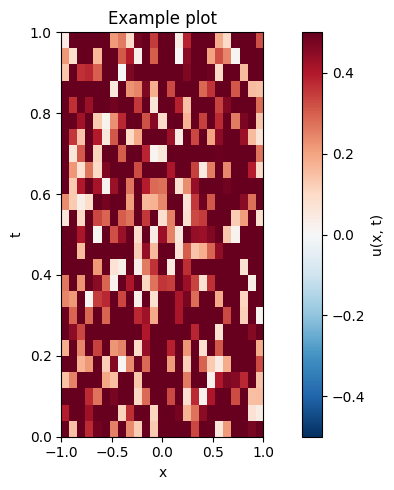

In [146]:
u.show(title="Example plot")

Now, we can set up our functional.

In [147]:
import jax
import jax.numpy as jnp

In [148]:
class DiscretePDELoss:
    def __init__(self, u: Wavefield):
        self.u = u

    # call to pass to scipy.optimize
    def __call__(self, params: jnp.ndarray) -> float:
        return self.evaluate(params)

    # evaluate full loss
    def evaluate(self, params: jnp.ndarray) -> float:
        R_pde = self._R_pde(params)
        R_cond = self._R_cond(params)
        return jnp.sum(R_pde**2) + jnp.sum(R_cond**2)

    # pde residual component
    def _R_pde(self, params):
        p = params.reshape(self.u.N, self.u.I)   # (time, space)
        utt = (p[2:, 1:-1] - 2*p[1:-1, 1:-1] + p[:-2, 1:-1])  / self.u.dt**2  # varies time
        uxx = (p[1:-1, 2:] - 2*p[1:-1, 1:-1] + p[1:-1, :-2])  / self.u.dx**2  # varies space
        return (utt - uxx).ravel()


    # boundary condition component
    def _R_cond(self, params: jnp.ndarray) -> jnp.ndarray:
        p = params.reshape(self.u.N, self.u.I)

        g_0_i = jnp.zeros(self.u.I)
        g_1_i = jnp.zeros(self.u.I)
        g_n_0 = jnp.zeros(self.u.N)
        g_n_I = jnp.zeros(self.u.N)

        xs = self.u.x_0 + jnp.arange(self.u.I) * self.u.dx
        ts = jnp.arange(self.u.N) * self.u.dt

        for k in range(1, 6):
            kpi = k * jnp.pi
            g_0_i += 0.1 * (jnp.cos((xs + 0.5) * kpi) + jnp.cos((xs - 0.5) * kpi))
            g_1_i += 0.1 * kpi * (jnp.sin((xs + 0.5) * kpi) - jnp.sin((xs - 0.5) * kpi))
            g_n_0 += 0.1 * (jnp.cos((self.u.x_0 - ts + 0.5) * kpi) + jnp.cos((self.u.x_0 + ts - 0.5) * kpi))
            g_n_I += 0.1 * (jnp.cos((self.u.x_I - ts + 0.5) * kpi) + jnp.cos((self.u.x_I + ts - 0.5) * kpi))

        return jnp.concatenate([
            p[0, :] - g_0_i,
            (p[1, :] - p[0, :]) / self.u.dt - g_1_i, # u_t(x, 0) = g_1_i
            p[:, 0]  - g_n_0,
            p[:, -1] - g_n_I,
        ])

## Optimising

Now, we have all we need to optimise using `scipy`'s L-BFGS-B. Let's give this a go.

In [149]:
import scipy.optimize as scopt

In [150]:
# setup and optimise
u = Wavefield() # instantiate with zeros
functional = DiscretePDELoss(u)

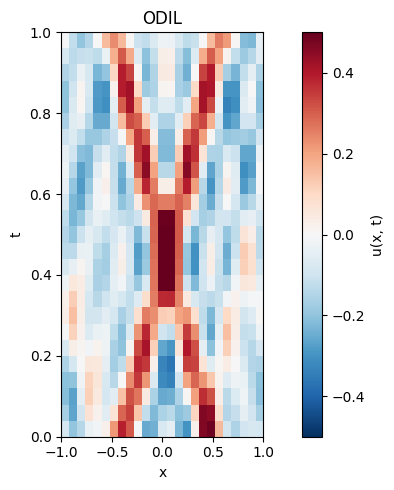

In [151]:
# jit compile gradient function
f_jit = jax.jit(functional)
grad_f = jax.jit(jax.grad(functional)) # specify the gradient using jax

# optimise
result = scopt.minimize(
    functional,
    x0=u._data.copy(),
    jac=grad_f,
    method='L-BFGS-B',
    options={'maxiter': 10000, 'ftol': 1e-12, 'gtol': 1e-8}
)

u._data = result.x
u.show('ODIL')